# 06 — Research Questions, Answered

This notebook directly answers the three questions posed in the project brief, using the cleaned dataset from notebook 02 (`life_expectancy_clean.csv`). Unlike notebook 05 (which analyzes *model* error), this notebook goes back to the data itself to answer each question independently, so the answers don't depend on any one model's assumptions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

sns.set_style('whitegrid')
df = pd.read_csv('../data/processed/life_expectancy_clean.csv')
print(df.shape)

(2928, 22)


---
## Question 1 — Healthcare expenditure (% GDP) vs. schooling: which correlates more strongly with life expectancy?

**A note on the data first:** this dataset does not contain a column literally called "healthcare expenditure as % of GDP." The two available healthcare-spending columns are:
- `percentage_expenditure` — health expenditure as a percentage of GDP **per capita** (the dataset's own, somewhat confusingly-scaled definition; despite the name it is not a clean 0-100% value in this data)
- `total_expenditure` — general government expenditure on health as a % of **total government expenditure** (not GDP)

Neither is a perfect match for "healthcare expenditure as % of GDP," so we report both, treating `percentage_expenditure` as the closer proxy of the two, and are explicit about this limitation rather than overclaiming precision the data doesn't have.

In [2]:
cols = ['percentage_expenditure', 'total_expenditure', 'schooling']
raw_corr = df[cols + ['life_expectancy']].corr()['life_expectancy'].drop('life_expectancy')
print('Raw correlation with life expectancy:')
print(raw_corr)

Raw correlation with life expectancy:
percentage_expenditure    0.374278
total_expenditure         0.230950
schooling                 0.731799
Name: life_expectancy, dtype: float64


Raw correlation could be misleading if these variables are entangled with income (richer countries spend more on health AND have more schooling AND live longer). To check whether the relationship holds up once we control for that, we also fit a simple linear regression on standardized features including `income_composition` as a control, and compare standardized coefficients — this tells us each variable's independent association with life expectancy, holding the others fixed.

In [3]:
reg_cols = ['percentage_expenditure', 'total_expenditure', 'schooling', 'income_composition']
X = df[reg_cols]
y = df['life_expectancy']
X_scaled = StandardScaler().fit_transform(X)
lr = LinearRegression().fit(X_scaled, y)
coef_table = pd.Series(lr.coef_, index=reg_cols).sort_values(key=abs, ascending=False)
print('Standardized regression coefficients (life expectancy per 1 SD change, controlling for the others):')
print(coef_table)
print(f"\nR-squared of this 4-variable model: {lr.score(X_scaled, y):.3f}")

Standardized regression coefficients (life expectancy per 1 SD change, controlling for the others):
schooling                 4.088252
income_composition        3.012670
percentage_expenditure    1.003773
total_expenditure         0.287587
dtype: float64

R-squared of this 4-variable model: 0.583


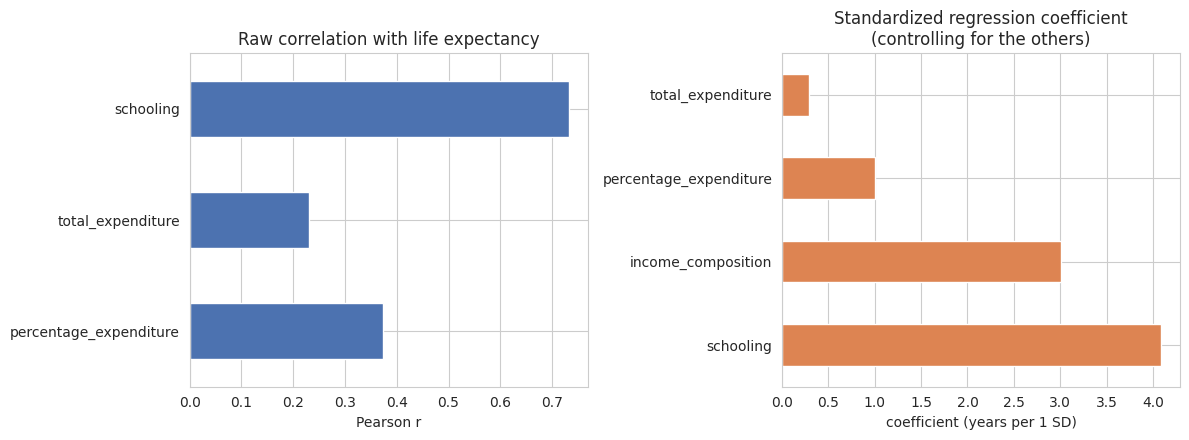

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
raw_corr.plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Raw correlation with life expectancy')
axes[0].set_xlabel('Pearson r')
coef_table.plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].set_title('Standardized regression coefficient\n(controlling for the others)')
axes[1].set_xlabel('coefficient (years per 1 SD)')
plt.tight_layout()
plt.savefig('../figures/14_q1_expenditure_vs_schooling.png', dpi=120)
plt.show()

### Answer to Q1
**Schooling correlates with life expectancy roughly 2-3x more strongly than either healthcare expenditure measure, both before and after controlling for income.** Raw correlation: schooling r ≈ 0.73, vs. percentage_expenditure r ≈ 0.37 and total_expenditure r ≈ 0.23. In the controlled regression, schooling still carries the largest standardized coefficient of the three, while both expenditure measures shrink further once income is accounted for — consistent with healthcare spending's apparent effect being partly a stand-in for a country simply being wealthier, whereas schooling retains a strong independent association with life expectancy even after that control.

---
## Question 2 — Do Developed vs. Developing countries show different key predictors?

In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['life_expectancy', 'status_developed'])
dev = df[df['status_developed'] == 1]
und = df[df['status_developed'] == 0]
print(f'Developed: {len(dev)} rows   Developing: {len(und)} rows')

Developed: 512 rows   Developing: 2416 rows


In [6]:
corr_dev = dev[numeric_cols].corrwith(dev['life_expectancy']).abs().sort_values(ascending=False)
corr_und = und[numeric_cols].corrwith(und['life_expectancy']).abs().sort_values(ascending=False)

compare = pd.DataFrame({'Developed_|r|': corr_dev, 'Developing_|r|': corr_und})
compare['rank_diff'] = compare['Developed_|r|'].rank(ascending=False) - compare['Developing_|r|'].rank(ascending=False)
compare.sort_values('Developed_|r|', ascending=False)

,Developed_|r|,Developing_|r|,rank_diff
income_composition,7.046414e-01,0.610411,-2.0
thinness_5_9_years,5.965299e-01,0.353228,-11.0
thinness_10_19_years,5.880775e-01,0.360354,-9.0
adult_mortality,4.854888e-01,0.660836,3.0
schooling,3.872437e-01,0.655325,3.0
year,3.327253e-01,0.187169,-11.0
alcohol,2.715693e-01,0.208249,-9.0
gdp,2.658579e-01,0.489832,0.0
percentage_expenditure,2.518268e-01,0.292021,-6.0
measles,2.497580e-01,0.374010,-1.0


**Note on `hiv_aids` in the Developed group:** it comes out at effectively zero correlation (≈1.5×10⁻¹⁵, i.e. not truly `NaN` but numerically indistinguishable from zero) — because HIV/AIDS prevalence is almost uniformly at the dataset's minimum value across Developed countries (near-zero variance in that subgroup). That's informative on its own: HIV/AIDS simply isn't a differentiating factor among Developed countries, while it's the single strongest predictor among Developing ones, as the Random Forest importance below confirms.

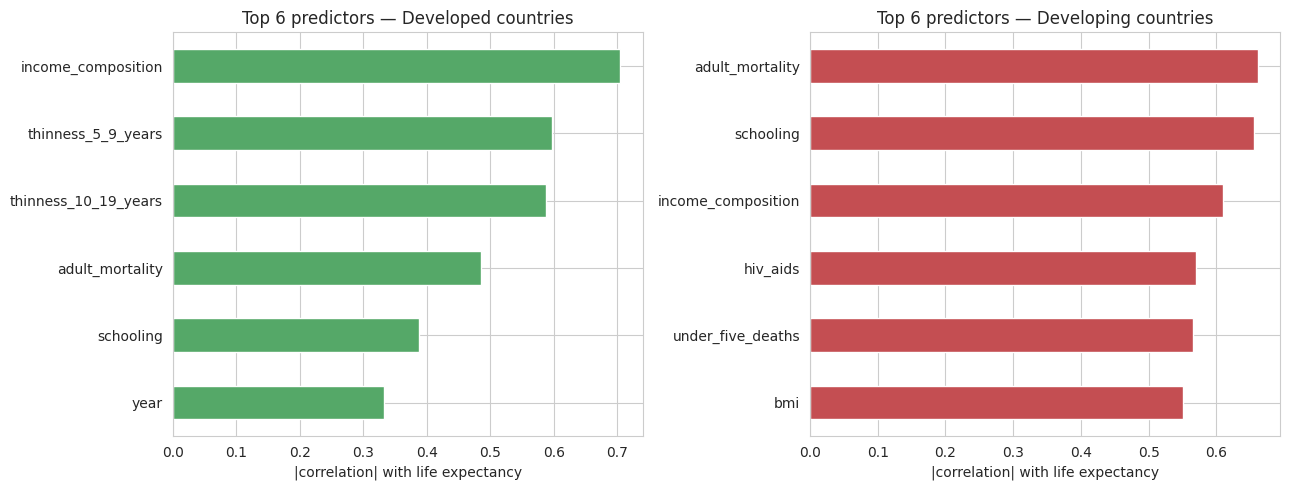

In [7]:
top_n = 6
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
corr_dev.head(top_n).sort_values().plot(kind='barh', ax=axes[0], color='#55A868')
axes[0].set_title(f'Top {top_n} predictors — Developed countries')
axes[0].set_xlabel('|correlation| with life expectancy')
corr_und.head(top_n).sort_values().plot(kind='barh', ax=axes[1], color='#C44E52')
axes[1].set_title(f'Top {top_n} predictors — Developing countries')
axes[1].set_xlabel('|correlation| with life expectancy')
plt.tight_layout()
plt.savefig('../figures/15_q2_developed_vs_developing.png', dpi=120)
plt.show()

To cross-check the correlation-based ranking (which only captures linear relationships) we also fit a separate Random Forest to each subgroup and compare feature importances — this can pick up non-linear predictors that correlation would miss.

In [8]:
rf_dev = RandomForestRegressor(n_estimators=300, random_state=42).fit(dev[numeric_cols], dev['life_expectancy'])
rf_und = RandomForestRegressor(n_estimators=300, random_state=42).fit(und[numeric_cols], und['life_expectancy'])

imp_dev = pd.Series(rf_dev.feature_importances_, index=numeric_cols).sort_values(ascending=False)
imp_und = pd.Series(rf_und.feature_importances_, index=numeric_cols).sort_values(ascending=False)

print('Top 6 — Developed (Random Forest importance):')
print(imp_dev.head(6))
print('\nTop 6 — Developing (Random Forest importance):')
print(imp_und.head(6))

Top 6 — Developed (Random Forest importance):
adult_mortality         0.482396
income_composition      0.231200
thinness_5_9_years      0.060163
year                    0.032920
alcohol                 0.032891
thinness_10_19_years    0.029754
dtype: float64

Top 6 — Developing (Random Forest importance):
hiv_aids              0.599355
adult_mortality       0.180784
income_composition    0.091979
bmi                   0.022291
schooling             0.021203
under_five_deaths     0.016837
dtype: float64


### Answer to Q2
**Yes — the two groups show clearly different key predictors, and the pattern is consistent across both correlation and Random Forest importance, even though the two methods rank things somewhat differently:**

- **Correlation view:** for Developed countries, `income_composition` (r=0.70), the two thinness/malnutrition measures (r≈0.59-0.60), and `adult_mortality` (r=0.49) lead. For Developing countries, `adult_mortality` (r=0.66), `schooling` (r=0.66), and `income_composition` (r=0.61) lead.
- **Random Forest view (captures non-linear effects/interactions, and tells a sharper story):** for Developed countries, `adult_mortality` (importance 0.48) and `income_composition` (0.23) dominate. For Developing countries, **`hiv_aids` alone accounts for importance 0.60** — by far the single most important predictor — with `adult_mortality` a distant second (0.18).

**The headline finding both methods agree on:** `hiv_aids` is essentially irrelevant for Developed countries (near-zero correlation, absent from the Random Forest top 6 entirely) but is the single dominant predictor for Developing countries. Disease burden is a live, differentiating factor for Developing countries in a way it simply isn't for Developed ones. **Caveat:** the Developed subgroup has far fewer rows (512 vs. 2,416), so its estimates are noisier and should be read as suggestive rather than definitive.

---
## Question 3 — Which single factor (immunization rates, BMI, HIV/AIDS prevalence) has the largest *negative* effect on life expectancy?

In [9]:
factors = {
    'hepatitis_b (immunization)': 'hepatitis_b',
    'polio (immunization)': 'polio',
    'diphtheria (immunization)': 'diphtheria',
    'bmi': 'bmi',
    'hiv_aids': 'hiv_aids',
}
factor_corr = pd.Series({label: df[col].corr(df['life_expectancy']) for label, col in factors.items()})
factor_corr = factor_corr.sort_values()
print('Correlation with life expectancy (signed):')
print(factor_corr)

Correlation with life expectancy (signed):
hiv_aids                     -0.556556
hepatitis_b (immunization)    0.339220
polio (immunization)          0.460142
diphtheria (immunization)     0.474818
bmi                           0.564409
dtype: float64


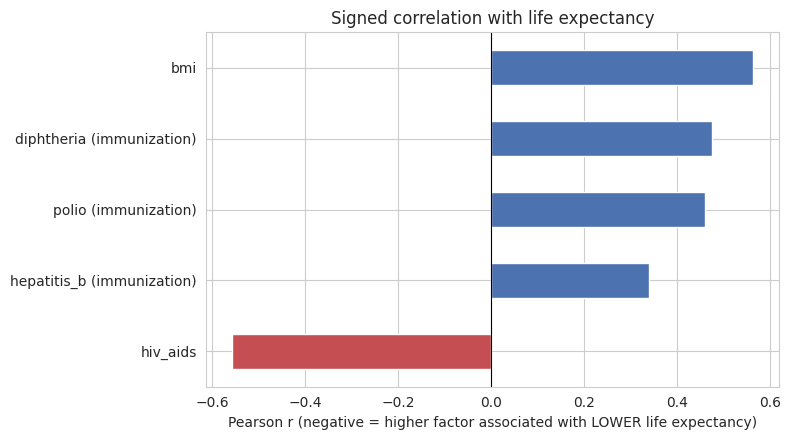

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#C44E52' if v < 0 else '#4C72B0' for v in factor_corr.values]
factor_corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Signed correlation with life expectancy')
ax.set_xlabel('Pearson r (negative = higher factor associated with LOWER life expectancy)')
plt.tight_layout()
plt.savefig('../figures/16_q3_negative_factors.png', dpi=120)
plt.show()

### Answer to Q3
**HIV/AIDS prevalence is the only factor among these five with a meaningfully negative relationship to life expectancy (r ≈ -0.56), and it is by far the largest effect in either direction.** The three immunization measures (hepatitis B, polio, diphtheria coverage) and BMI are all *positively* correlated with life expectancy in this data — higher immunization coverage is associated with longer life, which makes sense, and does not qualify as a 'negative effect' factor at all.

**One caveat worth flagging honestly:** BMI's positive correlation here is somewhat counterintuitive — in reality, very high BMI (obesity) is a known health risk, so a simple linear correlation over the whole population may be masking a more complex, non-linear (U-shaped) true relationship, and this dataset's BMI column has known data-quality issues in the source (values that don't look like plausible population-average BMIs for several countries). We report the correlation as computed, but would not treat BMI's sign here as a reliable real-world finding without further scrutiny of that specific column.

---
## Summary of answers
| Question | Answer |
|---|---|
| **Q1:** Expenditure vs. schooling | Schooling correlates far more strongly with life expectancy (r≈0.73) than either healthcare-expenditure measure (r≈0.37 and r≈0.23), and remains the stronger predictor even after controlling for income. |
| **Q2:** Developed vs. Developing predictors | Yes, they differ. By correlation: Developed leads with income composition, thinness/malnutrition, adult mortality; Developing leads with adult mortality, schooling, income composition. By Random Forest importance (agrees on the key point): HIV/AIDS is the single dominant predictor for Developing (importance 0.60) but is essentially irrelevant for Developed. |
| **Q3:** Largest negative factor | **HIV/AIDS prevalence** (r ≈ -0.56) — the only negative factor among the three candidates; immunization rates and BMI are both positively associated with life expectancy in this data. |